In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================
# LOAD DATASET
# ==============================

file_path = "heart_2020_cleaned.csv"

df = pd.read_csv(file_path)

# Display first five rows
print("First 5 rows of the dataset:")
display(df.head())

# Dataset shape
print("Dataset shape:")
print(df.shape)

First 5 rows of the dataset:


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


Dataset shape:
(230703, 18)


In [2]:
# ==============================
# BASIC DATASET INFORMATION
# ==============================

print("Dataset information:")
df.info()

print("\nColumn names:")
print(df.columns.tolist())

print("\nStatistical summary:")
display(df.describe())

print("\nCategorical column summary:")
display(df.describe(include="object"))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230703 entries, 0 to 230702
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      230703 non-null  object 
 1   BMI               230703 non-null  float64
 2   Smoking           230703 non-null  object 
 3   AlcoholDrinking   230703 non-null  object 
 4   Stroke            230703 non-null  object 
 5   PhysicalHealth    230703 non-null  int64  
 6   MentalHealth      230703 non-null  int64  
 7   DiffWalking       230703 non-null  object 
 8   Sex               230703 non-null  object 
 9   AgeCategory       230703 non-null  object 
 10  Race              230703 non-null  object 
 11  Diabetic          230703 non-null  object 
 12  PhysicalActivity  230703 non-null  object 
 13  GenHealth         230703 non-null  object 
 14  SleepTime         230703 non-null  int64  
 15  Asthma            230703 non-null  object 
 16 

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,230703.000000,230703.000000,230703.000000,230703.000000
mean,28.304489,3.327451,3.883040,7.102630
std,6.349549,7.898767,7.928839,1.439556
min,12.020000,0.000000,0.000000,1.000000
25%,24.015000,0.000000,0.000000,6.000000
50%,27.320000,0.000000,0.000000,7.000000
75%,31.380000,2.000000,3.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000



Categorical column summary:


,HeartDisease,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,Asthma,KidneyDisease,SkinCancer
count,230703,230703,230703,230703,230703,230703,230703,230703,230703,230703,230703,230703,230702,230702
unique,2,2,2,2,2,2,13,6,4,2,5,2,2,2
top,No,No,No,No,No,Female,65-69,White,No,Yes,Very good,No,No,No
freq,210915,134226,214705,221909,198665,121202,24720,177823,194676,179087,82695,200354,222212,209094


In [3]:
# ==============================
# CHECK NULL VALUES
# ==============================

print("Missing values in each column:")
null_values = df.isnull().sum()
print(null_values)

print("\nTotal missing values:")
print(df.isnull().sum().sum())

# ==============================
# CHECK DUPLICATES
# ==============================

duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:")
print(duplicate_count)

Missing values in each column:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       1
SkinCancer          1
dtype: int64

Total missing values:
2

Number of duplicate rows:
10524


In [4]:
# ==============================
# CLEAN COLUMN NAMES
# ==============================

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

print("Updated column names:")
print(df.columns.tolist())

Updated column names:
['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [5]:
# ==============================
# REMOVE DUPLICATES
# ==============================

print("Shape before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Shape before removing duplicates: (230703, 18)
Shape after removing duplicates: (220179, 18)
Remaining duplicate rows: 0


In [6]:
# ==============================
# TARGET COLUMN DISTRIBUTION
# ==============================

target_col = "HeartDisease"

print("Target column value counts:")
print(df[target_col].value_counts())

print("\nTarget column percentage:")
print(df[target_col].value_counts(normalize=True) * 100)

Target column value counts:
HeartDisease
No     200455
Yes     19724
Name: count, dtype: int64

Target column percentage:
HeartDisease
No     91.041834
Yes     8.958166
Name: proportion, dtype: float64


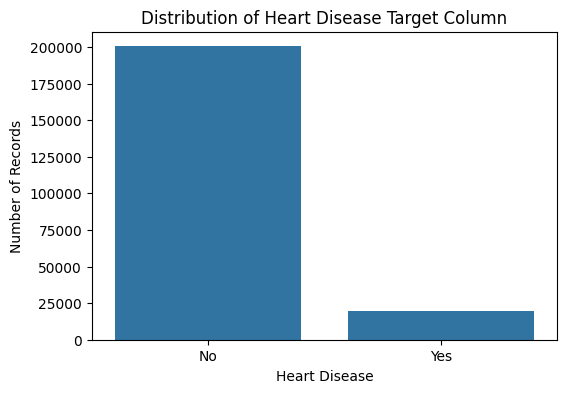

In [7]:
# ==============================
# TARGET DISTRIBUTION PLOT
# ==============================

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Distribution of Heart Disease Target Column")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Records")
plt.show()

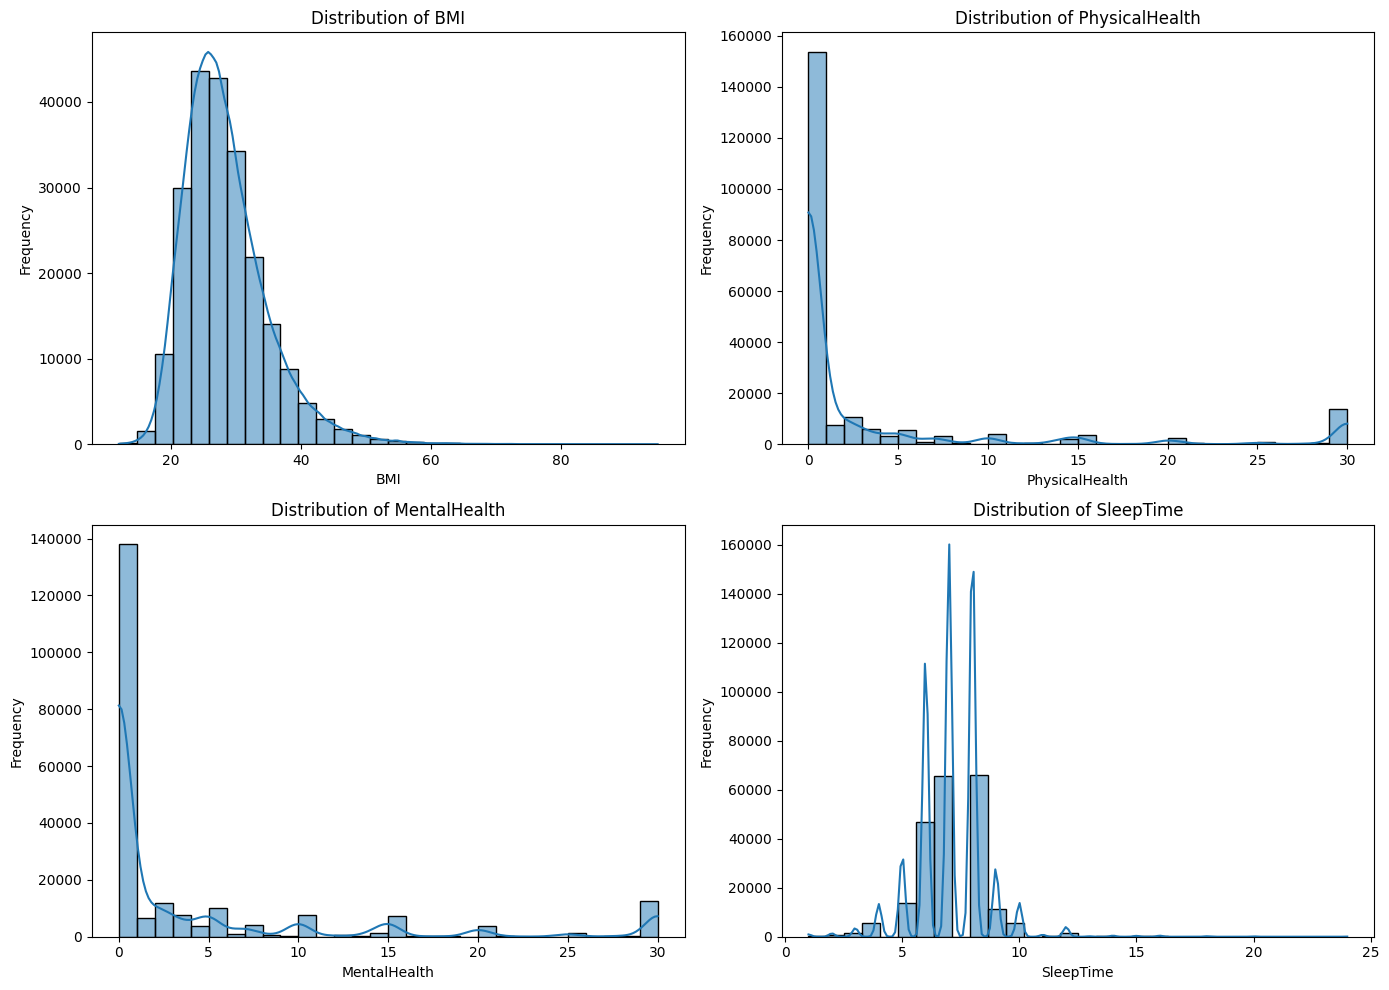

In [10]:
# ============================================================
# CELL 8: NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

num_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

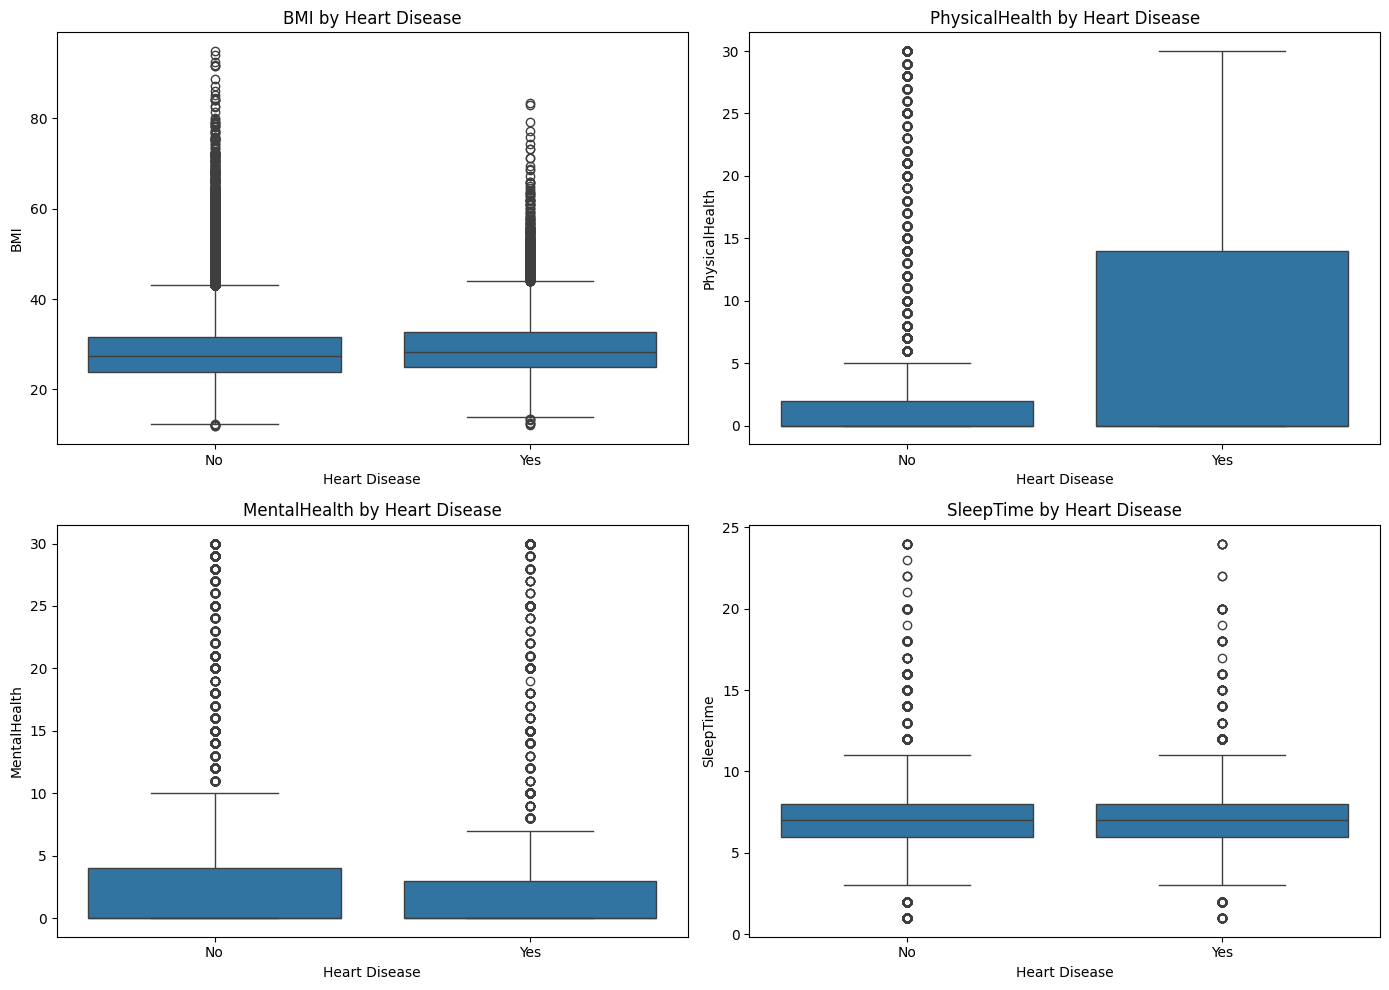

In [11]:
# ============================================================
# CELL 9: NUMERICAL FEATURES BY HEART DISEASE
# ============================================================

num_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=col,
        order=["No", "Yes"]
    )
    plt.title(f"{col} by Heart Disease")
    plt.xlabel("Heart Disease")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

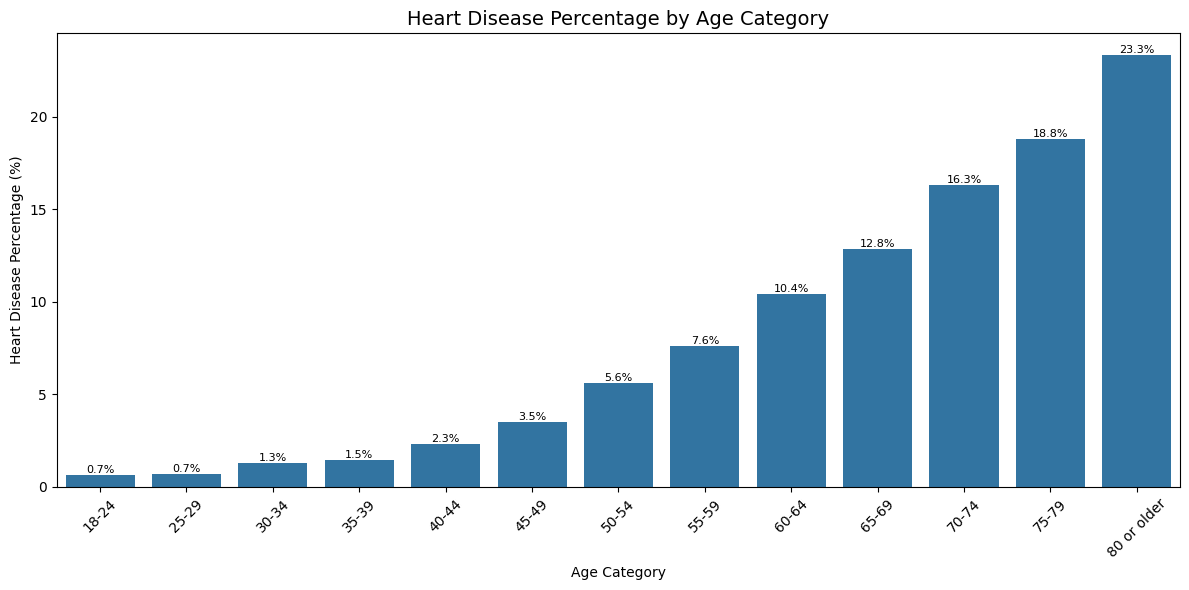

,AgeCategory,HeartDiseasePercentage
0,18-24,0.650159
1,25-29,0.715442
2,30-34,1.279877
3,35-39,1.480065
4,40-44,2.318841
5,45-49,3.484203
6,50-54,5.631034
7,55-59,7.610837
8,60-64,10.397380
9,65-69,12.840484


In [12]:
# ============================================================
# CELL 10: HEART DISEASE PERCENTAGE BY AGE CATEGORY
# ============================================================

age_order = [
    "18-24", "25-29", "30-34", "35-39", "40-44",
    "45-49", "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79", "80 or older"
]

age_heart_rate = (
    df.groupby("AgeCategory")["HeartDisease"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(age_order)
    .reset_index()
)

age_heart_rate.columns = ["AgeCategory", "HeartDiseasePercentage"]

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=age_heart_rate,
    x="AgeCategory",
    y="HeartDiseasePercentage"
)

plt.title("Heart Disease Percentage by Age Category", fontsize=14)
plt.xlabel("Age Category")
plt.ylabel("Heart Disease Percentage (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.tight_layout()
plt.show()

display(age_heart_rate)

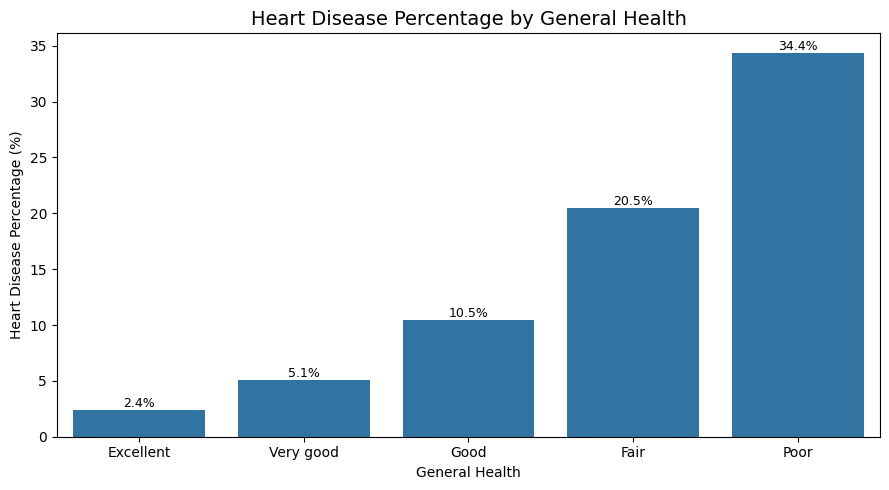

,GenHealth,HeartDiseasePercentage
0,Excellent,2.371416
1,Very good,5.094710
2,Good,10.489850
3,Fair,20.506659
4,Poor,34.393564


In [13]:
# ============================================================
# CELL 11: HEART DISEASE PERCENTAGE BY GENERAL HEALTH
# ============================================================

genhealth_order = ["Excellent", "Very good", "Good", "Fair", "Poor"]

genhealth_rate = (
    df.groupby("GenHealth")["HeartDisease"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(genhealth_order)
    .reset_index()
)

genhealth_rate.columns = ["GenHealth", "HeartDiseasePercentage"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=genhealth_rate,
    x="GenHealth",
    y="HeartDiseasePercentage"
)

plt.title("Heart Disease Percentage by General Health", fontsize=14)
plt.xlabel("General Health")
plt.ylabel("Heart Disease Percentage (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()
plt.show()

display(genhealth_rate)

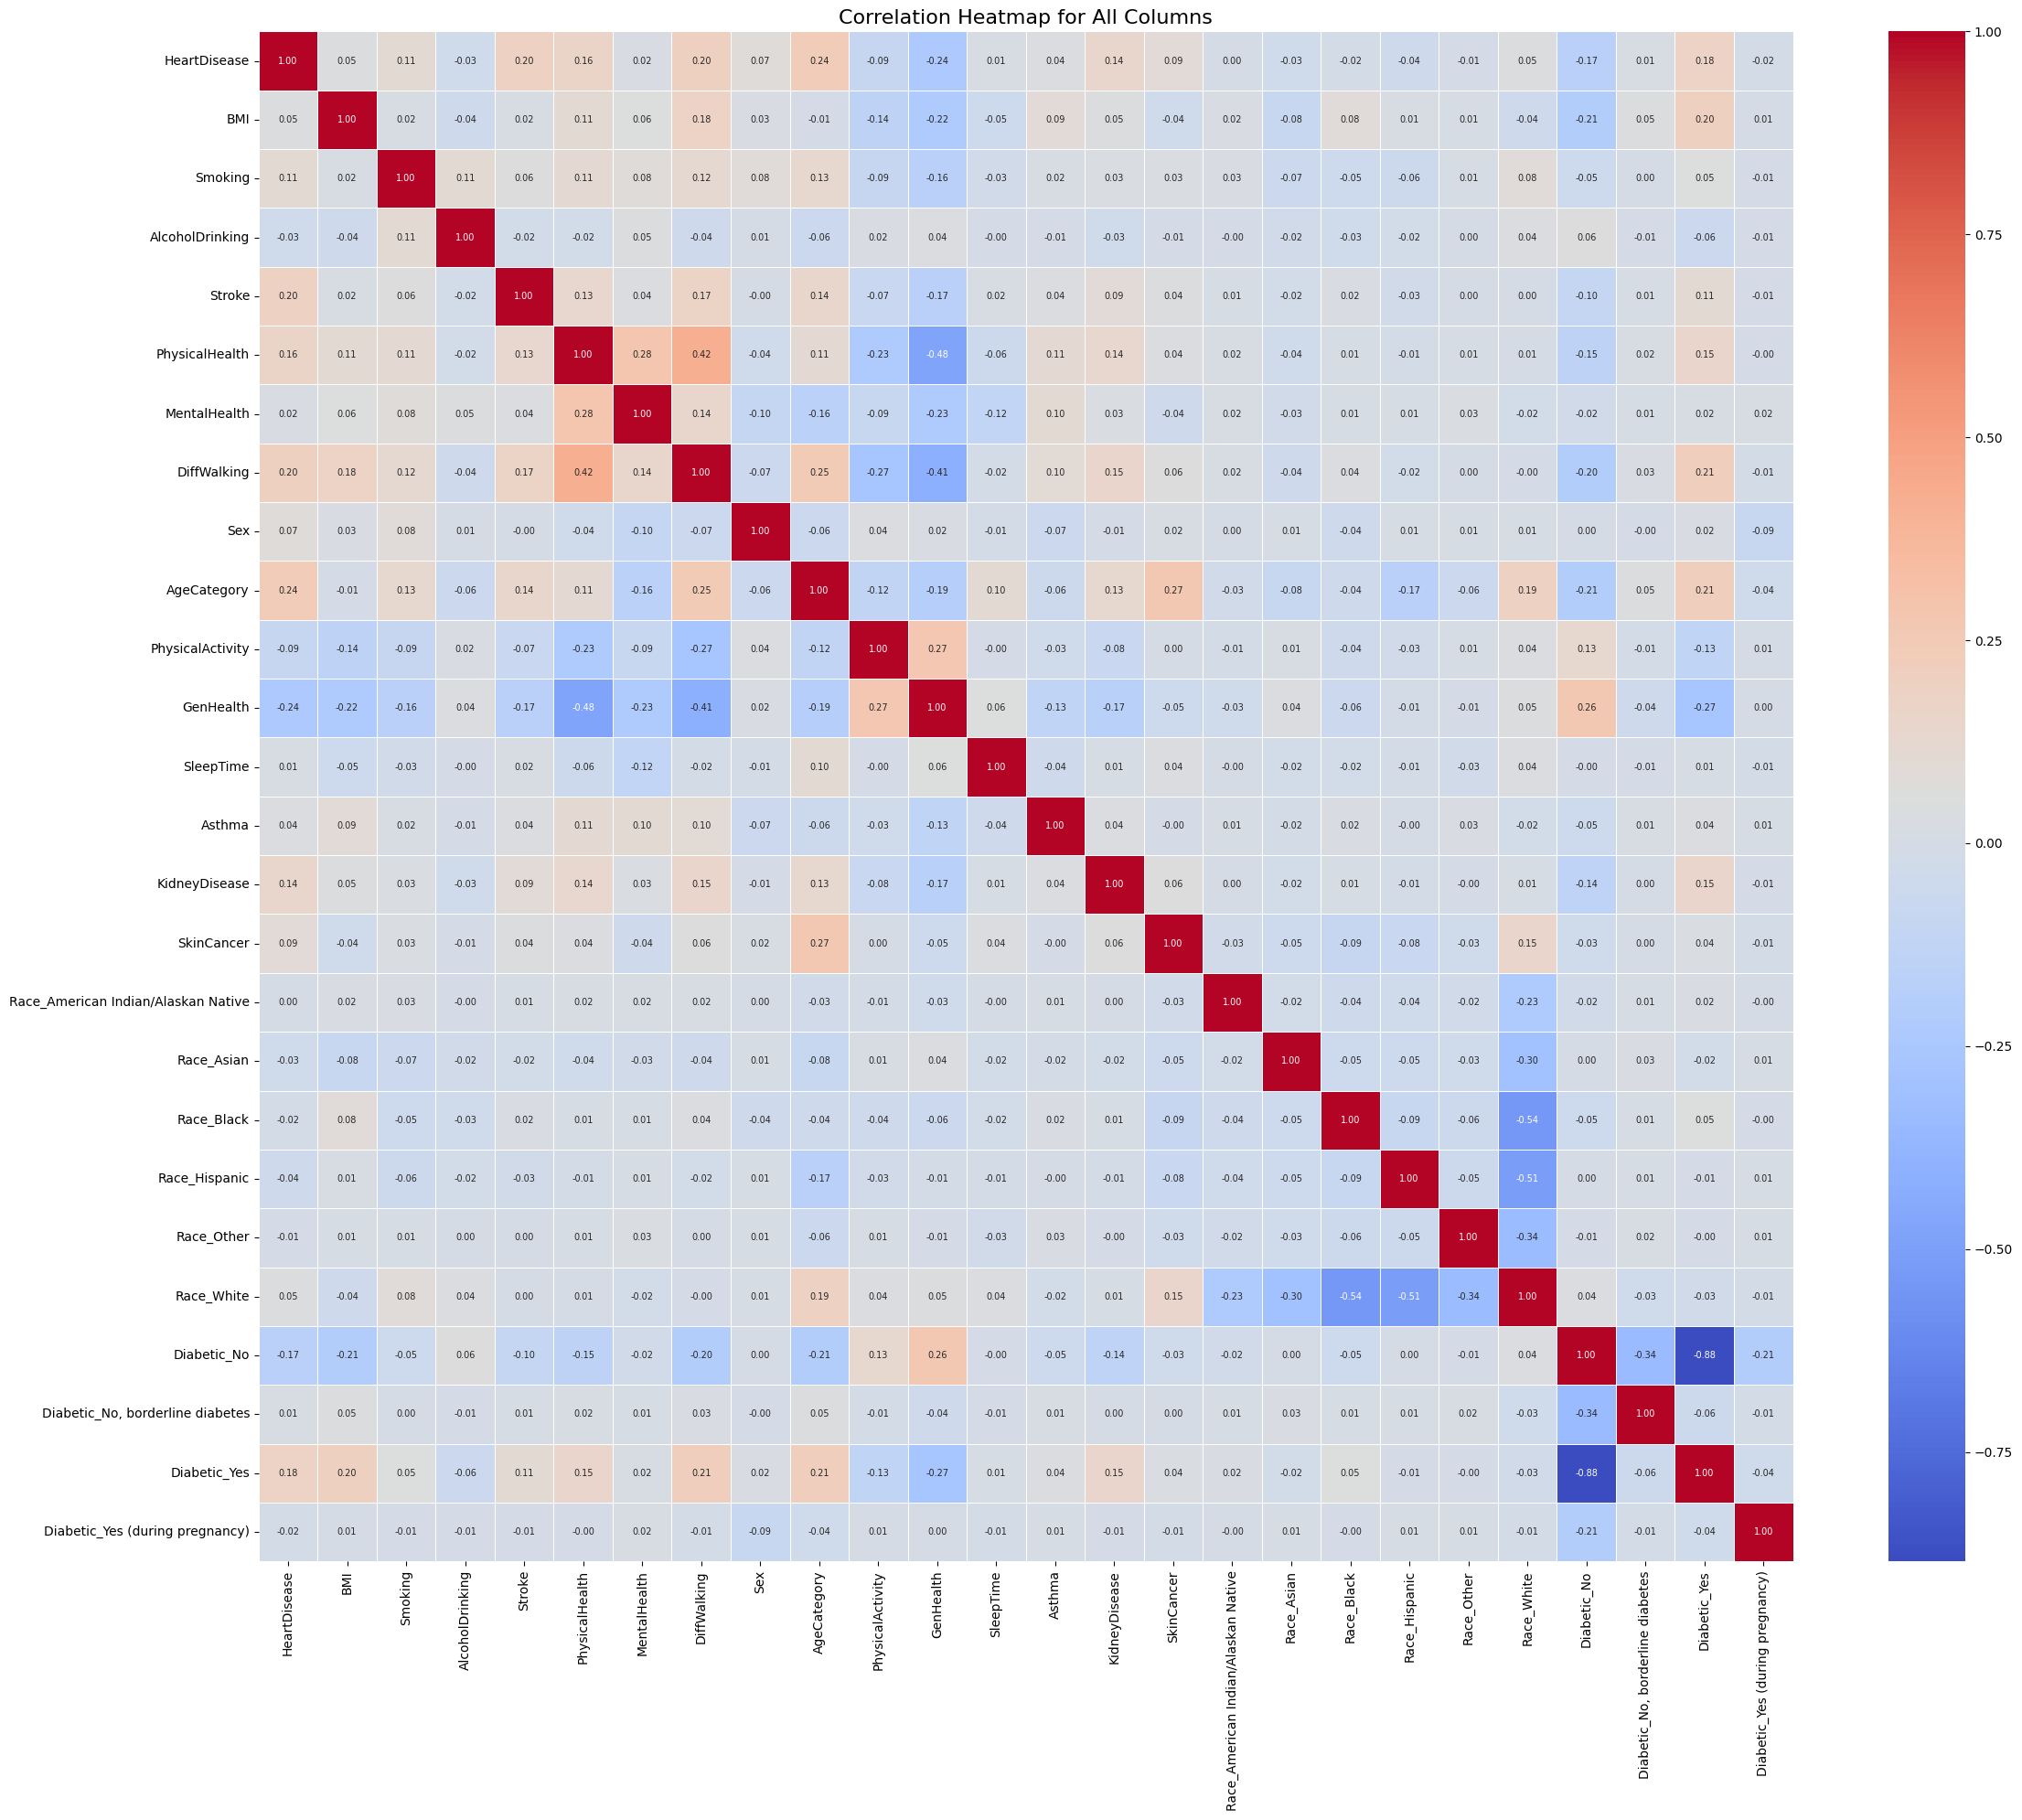

In [15]:
# ============================================================
# CORRELATION HEATMAP FOR ALL COLUMNS
# ============================================================
# This cell creates a correlation heatmap using all columns.
# Categorical columns are encoded safely.
# Original df is not changed.
# ============================================================

# Create copy
heatmap_df = df.copy()

# Remove extra spaces from text values
for col in heatmap_df.select_dtypes(include="object").columns:
    heatmap_df[col] = heatmap_df[col].astype(str).str.strip()

# Encode Yes/No columns
yes_no_cols = [
    "HeartDisease", "Smoking", "AlcoholDrinking", "Stroke",
    "DiffWalking", "PhysicalActivity", "Asthma",
    "KidneyDisease", "SkinCancer"
]

for col in yes_no_cols:
    heatmap_df[col] = heatmap_df[col].map({"No": 0, "Yes": 1})

# Encode Sex
heatmap_df["Sex"] = heatmap_df["Sex"].map({"Female": 0, "Male": 1})

# Encode AgeCategory in correct order
age_map = {
    "18-24": 1,
    "25-29": 2,
    "30-34": 3,
    "35-39": 4,
    "40-44": 5,
    "45-49": 6,
    "50-54": 7,
    "55-59": 8,
    "60-64": 9,
    "65-69": 10,
    "70-74": 11,
    "75-79": 12,
    "80 or older": 13
}

heatmap_df["AgeCategory"] = heatmap_df["AgeCategory"].map(age_map)

# Encode GenHealth in ordered form
# Higher value means better general health
genhealth_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very good": 4,
    "Excellent": 5
}

heatmap_df["GenHealth"] = heatmap_df["GenHealth"].map(genhealth_map)

# One-hot encode remaining categorical columns
heatmap_df = pd.get_dummies(
    heatmap_df,
    columns=["Race", "Diabetic"],
    drop_first=False,
    dtype=int
)

# Convert all columns to numeric safely
heatmap_df = heatmap_df.apply(pd.to_numeric, errors="coerce")

# Fill any remaining NaN values with 0
heatmap_df = heatmap_df.fillna(0)

# Create correlation matrix
corr_matrix = heatmap_df.corr()

# Plot heatmap
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap for All Columns", fontsize=16)
plt.tight_layout()
plt.show()